# Merge and Export Machine Learning Dataset
This notebook gathers all the pre-calculated features from the other scripts (OSM POIs, Land Use percentages, and Terrain Slope) and merges them into one single comprehensive `.csv` table that will be fed to the Machine Learning models.

## Note: Data Requirements

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datatsets

In [2]:
# Define file paths (UNCOMMENT AND ADJUST ONCE YOU HAVE EXPORTED THE DATA)

path_osm_roads = "data/osm_roads_noise_regre.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points = "data/osm_points_features.csv"
path_osmlanduse = "data/osm_landuse_features.csv"

df_osm_roads = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points = pd.read_csv(path_osm_points)
df_osm_landuse = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,13859746870_13859746860_0,55,55,50,5,213.093233,509.628452,1110.052349,188.355179,0.0,385.612798
1,13798851565_8465472214_0,50,50,45,5,173.078014,1621.681034,2110.530434,351.777378,0.0,117.669324
2,4538123419_13734642240_0,65,65,60,3,904.118521,947.154817,0.000000,167.026629,0.0,19.810222
3,13845167536_847716886_0,50,50,45,5,1877.603526,414.648395,661.587375,10.597441,0.0,41.365655
4,13845167536_253790691_0,55,55,50,5,1872.177506,607.144241,967.746460,0.000000,0.0,49.109562


In [4]:
df_momepy_roads.drop(['openness'], axis=1, inplace=True)  # Drop 'openness' to avoid duplication
df_momepy_roads.head()

,road_id,width,betweenness,closeness_global,closeness_400,straightness
0,21638845_885308258_0,43.025602,0.000896,0.000147,0.000006,0.798398
1,21638845_13175411896_0,26.114886,0.002015,0.000154,0.000011,0.812345
2,21638865_30343650_0,15.135908,0.000224,0.000161,0.000031,0.822206
3,21638867_1636238503_0,18.154330,0.002529,0.000168,0.000048,0.831058
4,21638867_1403082237_0,20.158620,0.002416,0.000168,0.000050,0.829978


In [5]:
df_osm_points.head()

,road_id,signals,transport,pois
0,21638845_885308258_0,0.105877,0.000000,0.070585
1,21638845_13175411896_0,0.022710,0.008111,0.014599
2,21638865_30343650_0,0.000000,0.000000,0.427369
3,21638867_1636238503_0,0.063558,0.000000,0.254232
4,21638867_1403082237_0,0.064862,0.000000,0.194587


In [6]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,21638845_885308258_0,9.169742,0.0,0.0
1,21638845_13175411896_0,1.024610,0.0,0.0
2,21638865_30343650_0,0.000000,0.0,0.0
3,21638867_1636238503_0,0.000000,0.0,0.0
4,21638867_1403082237_0,0.000000,0.0,0.0


## Merge dataframes

In [7]:
# Function to merge feature DataFrame with base DataFrame

def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    # Drop target columns
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    
    # Drop duplicate columns (except road_id)
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    
    # Ensure road_id exists and is consistent
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    
    return base_df.merge(clean_df, on='road_id', how='left')

In [8]:

ml_dataset = df_osm_roads.copy()

# Columns to remove to avoid repetition
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

# Check road_id types before merging
print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points', df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse', df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,13859746870_13859746860_0,55,55,50,5,213.093233,509.628452,1110.052349,188.355179,0.0,...,0.000000,0.106597,50.000000,0.000039,0.000187,0.000017,0.807756,3.349277,0.0,0.0
1,13798851565_8465472214_0,50,50,45,5,173.078014,1621.681034,2110.530434,351.777378,0.0,...,0.014274,0.000000,20.006115,0.000224,0.000109,0.000004,0.741368,0.000000,0.0,0.0
2,4538123419_13734642240_0,65,65,60,3,904.118521,947.154817,0.000000,167.026629,0.0,...,0.000000,0.295484,50.000000,0.010452,0.000182,0.000018,0.831327,8.619238,0.0,0.0
3,13845167536_847716886_0,50,50,45,5,1877.603526,414.648395,661.587375,10.597441,0.0,...,0.012453,0.002491,16.759462,0.004427,0.000215,0.000009,0.757172,4.346695,0.0,0.0
4,13845167536_253790691_0,55,55,50,5,1872.177506,607.144241,967.746460,0.000000,0.0,...,0.053513,0.000000,50.000000,0.003735,0.000208,0.000006,0.736805,25.169641,0.0,0.0
5,13859746847_13859746858_0,55,55,50,5,230.461136,497.475621,1128.775368,207.822288,0.0,...,0.000000,0.152217,50.000000,0.000405,0.000186,0.000017,0.806515,7.944880,0.0,0.0
6,13859746849_627782660_0,55,55,50,5,252.501664,464.074440,1149.354206,192.034337,0.0,...,0.000000,0.000000,50.000000,0.000942,0.000186,0.000015,0.802243,10.383405,0.0,0.0
7,13859746849_13859746858_0,55,55,50,5,230.461136,494.885556,1130.439275,207.822288,0.0,...,0.000000,0.089401,50.000000,0.000312,0.000186,0.000017,0.805332,8.043215,0.0,0.0
8,4538123419_4834501656_0,65,65,60,5,896.532099,963.938765,0.000000,190.766643,0.0,...,0.000000,0.375257,50.000000,0.002713,0.000182,0.000018,0.832442,4.635369,0.0,0.0
9,13859746854_13859746849_0,55,55,50,5,234.556285,494.885556,1127.661390,207.460174,0.0,...,0.000000,0.045574,50.000000,0.000706,0.000187,0.000017,0.805515,6.663638,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                12854 non-null  str    
 1   noise_day              12854 non-null  int64  
 2   noise_evening          12854 non-null  int64  
 3   noise_night            12854 non-null  int64  
 4   road_category          12854 non-null  int64  
 5   dist_to_trunk          12854 non-null  float64
 6   dist_to_primary        12854 non-null  float64
 7   dist_to_secondary      12854 non-null  float64
 8   dist_to_tertiary       12854 non-null  float64
 9   dist_to_residential    12854 non-null  float64
 10  dist_to_living_street  12854 non-null  float64
 11  signals                12854 non-null  float64
 12  transport              12854 non-null  float64
 13  pois                   12854 non-null  float64
 14  width                  12854 non-null  float64
 15  betweenness  

## Noise distribution

     Day  Evening   Night
35   132    158.0   419.0
40   130    243.0   613.0
45   452    599.0  1620.0
50  1181   1627.0  2827.0
55  2524   2902.0  3672.0
60  3441   3695.0  3008.0
65  3471   2951.0   695.0
70  1489    679.0     NaN
75    34      NaN     NaN


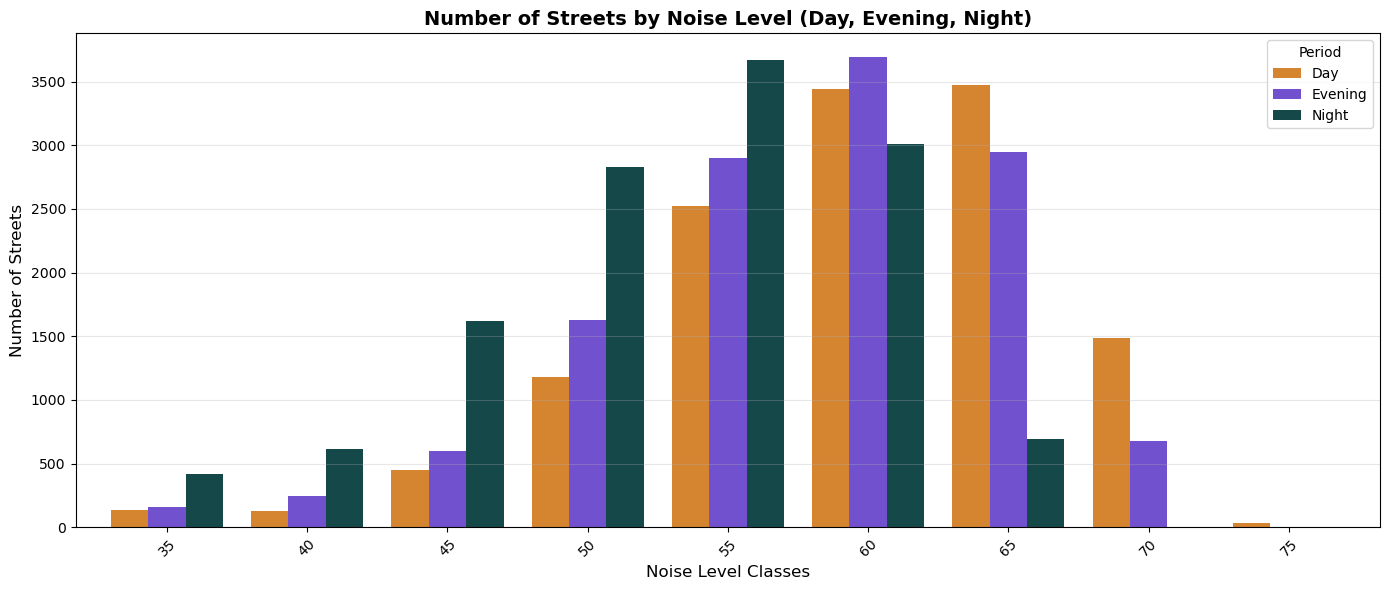

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_day = ml_dataset.groupby('noise_day').size()
counts_evening = ml_dataset.groupby('noise_evening').size()
counts_night = ml_dataset.groupby('noise_night').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Day': counts_day,
    'Evening': counts_evening,
    'Night': counts_night
})

print(comparison_df)
comparison_df[['Day', 'Evening', 'Night']].plot(kind='bar', ax=ax,width=0.8,color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level Classes', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export to CSV
Finally, we dump out the master table into a standard format readable by `scikit-learn` in the next phase!

In [10]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_regre_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_regre_ml_dataset.csv


## Subsample

In [11]:
import pandas as pd

# Assume your DataFrame is called df and the noise column is 'noise_day'
# Set the desired sample size (e.g., 1000)
sample_size = 5000

# Calculate the proportion of each noise value in the original data
proportions = ml_dataset['noise_day'].value_counts(normalize=True).sort_index()

# Calculate how many samples to take for each noise value
samples_per_value = (proportions * sample_size).round().astype(int)

# Subsample for each noise value
subsampled = pd.concat([
    ml_dataset[ml_dataset['noise_day'] == val].sample(n=n, random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

# Shuffle the result
subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(subsampled['noise_day'].value_counts(normalize=True).sort_index())

noise_day
35    0.010202
40    0.010202
45    0.035207
50    0.091818
55    0.196439
60    0.267654
65    0.270054
70    0.115823
75    0.002601
Name: proportion, dtype: float64


## Before and after sampling

           Before  After
noise_day               
35            132     51
40            130     51
45            452    176
50           1181    459
55           2524    982
60           3441   1338
65           3471   1350
70           1489    579
75             34     13


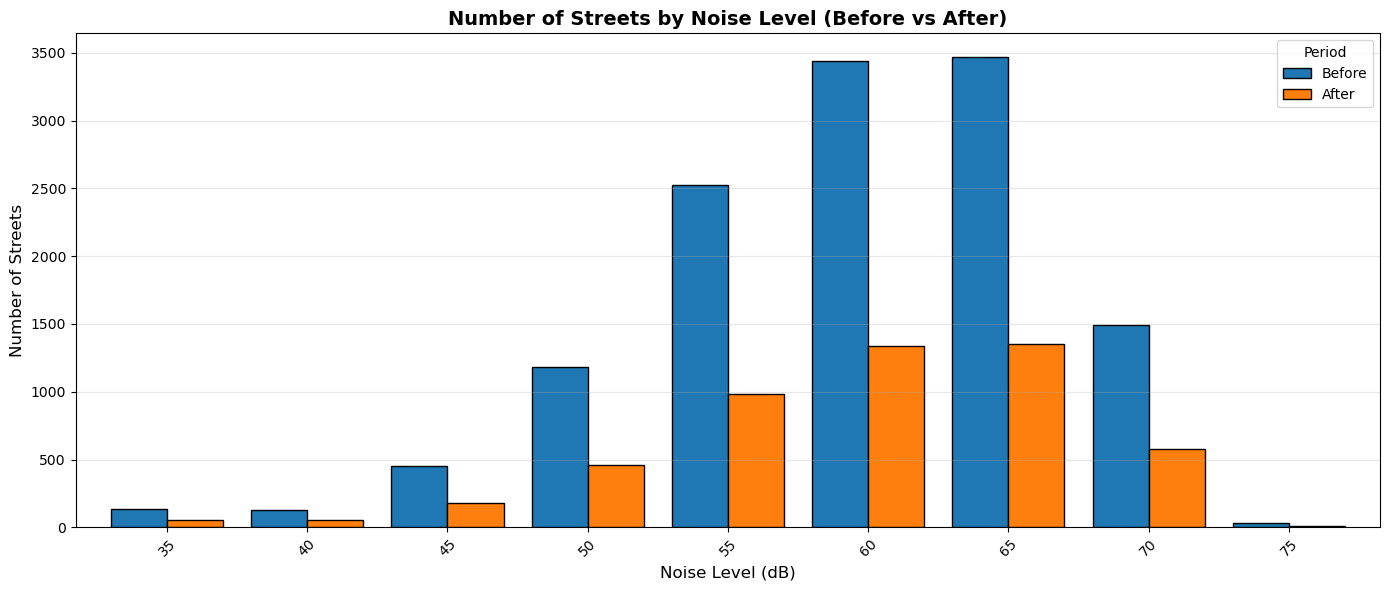

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_before = ml_dataset.groupby('noise_day').size()
counts_after = subsampled.groupby('noise_day').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Before': counts_before,
    'After': counts_after
})

print(comparison_df)
comparison_df[['Before', 'After']].plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export CSV

In [13]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_regre_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_regre_ml_subsample.csv
